# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды.

Выполнили студенты гр. 2381 Долотов Никита и Зазуля Илья. Вариант №18

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

**Генеральная совокупность** – полная совокупность объектов, характеристики которых изучаются в эксперименте.

**Выборка** – подмножество генеральной совокупности объёма $n$, отобранное для статистического анализа. При простой случайной бесповторной выборке каждый элемент имеет равную вероятность попасть в выборку, а отобранные элементы не возвращаются в совокупность.

**Ранжированный ряд** – последовательность значений выборки, упорядоченных по неубыванию:
$$x_{(1)} \leq x_{(2)} \leq \dots \leq x_{(n)}$$

**Вариационный ряд** – совокупность уникальных значений выборки $x_j$ с соответствующими абсолютными частотами $m_j$ (число появлений значения $x_j$ в выборке).

**Интервальный ряд** – таблица, полученная разбиением диапазона $[x_{min}, x_{max}]$ на $k$ частичных интервалов с подсчётом частот по каждому интервалу. Оптимальное число интервалов определяется по формуле Стёрджеса:
$$k = \lceil 1 + 3{,}322 \cdot \lg n \rceil$$

Ширина каждого интервала:
$$h = \frac{x_{max} - x_{min}}{k}$$

Границы $i$-го интервала ($i = 1, 2, \dots, k-1$):
$$[x_{min} + (i-1) \cdot h;\; x_{min} + i \cdot h)$$

Последний интервал замыкается с обеих сторон:
$$[x_{min} + (k-1) \cdot h;\; x_{min} + k \cdot h]$$

Середина $i$-го интервала:
$$\tilde{x}_i = \frac{(x_{min} + (i-1) \cdot h) + (x_{min} + i \cdot h)}{2}$$

Относительная частота $i$-го интервала:
$$\tilde{m}_i = \frac{m_i}{n}, \quad \sum_{i=1}^{k} \tilde{m}_i = 1$$

Накопленные частоты:
$$m_i^{нак} = \sum_{j=1}^{i} m_j, \qquad \tilde{m}_i^{нак} = \sum_{j=1}^{i} \tilde{m}_j$$

**Полигон частот** – ломаная линия, соединяющая точки $(\tilde{x}_i,\, m_i)$ для абсолютных или $(\tilde{x}_i,\, \tilde{m}_i)$ для относительных частот.

**Гистограмма** – столбчатая диаграмма, в которой каждому интервалу соответствует прямоугольник шириной $h$ и высотой $m_i$ (или $\tilde{m}_i$).

**Эмпирическая функция распределения** $F^*(x)$ определяет для каждого значения $x$ долю наблюдений, не превышающих $x$:
$$F^*(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}[x_i \leq x]$$

Для интервального ряда вычисляется в узлах:
$$F^*(\tilde{x}_i) = \frac{m_i^{нак}}{n}, \quad i = 1, 2, \dots, k$$

График $F^*(x)$ является монотонно неубывающей ступенчатой функцией, принимающей значения от 0 до 1.

## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

### Задание 1

Для выполнения работ выбран Python в среде Google Colab. Язык имеет готовые библиотеки для статистического анализа и визуализации (numpy, pandas, matplotlib) и широко применяется в научных вычислениях.

### Задание 2

Генеральная совокупность взята с [сайта курса](https://se.moevm.info/doku.php/courses:statistical_methods_of_experimental_data_handling:materials).

Данные содержат два вещественных признака: $\nu$ – объёмный вес древесины резонансной ели (г/см³) при влажности 10%, E – модуль упругости (кг/см²) при сжатии вдоль волокон. Объём генеральной совокупности – 400 наблюдений.

### Задание 3

Выборка объёмом 104 сформирована методом простой случайной бесповторной выборки. Каждый элемент имел равную вероятность попасть в выборку. Параметр `random_state=12` зафиксирован для воспроизводимости результатов.

In [10]:
import pandas as pd

df_population = pd.read_csv('sample.csv', comment='#')

df_sample = df_population.sample(n=104, replace=False, random_state=12)
df_sample = df_sample.reset_index(drop=True)

print(df_sample)

      nu      E
0    353   98.0
1    591  156.9
2    438  122.2
3    510  129.4
4    386  105.8
..   ...    ...
99   482  136.4
100  514  174.6
101  428  113.7
102  386   95.5
103  540  156.7

[104 rows x 2 columns]


### Задание 4



In [23]:
import numpy as np
import math

n = len(df_sample)
k = math.ceil(1 + 3.322 * math.log10(n))

def build_rows(df, column):
    print(f"\nРяды для признака: {column}")

    data = df[column]

    # Ранжированный ряд
    ranked = data.sort_values().reset_index(drop=True)
    ranked.index += 1
    print("\nРанжированный ряд:")
    print(ranked)

    # Вариационный ряд
    vals, counts = np.unique(ranked.values, return_counts=True)
    var_df = pd.DataFrame({"x": vals, "m_i": counts})
    print("\nВариационный ряд:")
    print(var_df.to_string(index=False))

    # Интервальный ряд
    xmin, xmax = float(data.min()), float(data.max())
    h = (xmax - xmin) / k
    bins = [xmin + i * h for i in range(k + 1)]
    bins[-1] += 1e-9

    rows = []
    m_cum = 0
    for i in range(k):
        left, right = bins[i], bins[i + 1]
        mask = (data >= left) & (data < right)
        m_i = int(mask.sum())
        m_cum += m_i
        rows.append({
            "i": i + 1,
            "[x_i, x_{i+1})": f"[{left:.2f}, {right:.2f})",
            "x̃_i": round((left + right) / 2, 2),
            "m_i": m_i,
            "~m_i": round(m_i / n, 4),
            "m_нак": m_cum,
            "~m_нак": round(m_cum / n, 4)
        })

    int_df = pd.DataFrame(rows)
    int_df.loc[len(int_df)] = {
        "i": "Σ", "[x_i, x_{i+1})": "", "x̃_i": "",
        "m_i": int_df["m_i"].sum(),
        "~m_i": round(int_df["~m_i"].sum(), 4),
        "m_нак": "-", "~m_нак": "-"
    }

    print(f"\nk = {k}, h = {h:.2f}, min = {xmin}, max = {xmax}")
    print("\nИнтервальный ряд:")
    display(int_df.set_index("i"))

    return h

for col in ["nu", "E"]:
    build_rows(df_sample, col)


Ряды для признака: nu

Ранжированный ряд:
1      344
2      353
3      371
4      382
5      386
      ... 
100    572
101    576
102    585
103    591
104    623
Name: nu, Length: 104, dtype: int64

Вариационный ряд:
  x  m_i
344    1
353    1
371    1
382    1
386    2
390    1
397    1
398    1
399    1
401    1
403    1
404    1
405    1
406    1
407    1
409    1
411    1
412    2
418    3
421    2
422    2
423    2
424    1
426    2
427    1
428    3
429    1
430    2
431    1
432    1
433    1
434    1
438    2
442    1
443    1
444    1
448    1
452    1
453    1
458    2
462    1
463    2
465    1
467    1
468    1
469    1
475    1
477    1
479    1
480    2
481    3
482    2
483    1
490    2
492    1
496    1
498    1
499    1
500    2
502    1
503    1
505    1
507    1
510    3
512    1
513    2
514    1
517    1
523    2
525    2
540    1
541    2
547    1
572    1
576    1
585    1
591    1
623    1

k = 8, h = 34.88, min = 344.0, max = 623.0

Интервальный ряд:


,"[x_i, x_{i+1})",x̃_i,m_i,~m_i,m_нак,~m_нак
i,,,,,,
1,"[344.00, 378.88)",361.44,3,0.0288,3,0.0288
2,"[378.88, 413.75)",396.31,17,0.1635,20,0.1923
3,"[413.75, 448.62)",431.19,29,0.2788,49,0.4712
4,"[448.62, 483.50)",466.06,22,0.2115,71,0.6827
5,"[483.50, 518.38)",500.94,20,0.1923,91,0.875
6,"[518.38, 553.25)",535.81,8,0.0769,99,0.9519
7,"[553.25, 588.12)",570.69,3,0.0288,102,0.9808
8,"[588.12, 623.00)",605.56,2,0.0192,104,1.0
Σ,,,104,0.9998,-,-



Ряды для признака: E

Ранжированный ряд:
1       86.8
2       91.4
3       91.9
4       94.3
5       95.3
       ...  
100    174.6
101    177.7
102    179.0
103    180.9
104    195.7
Name: E, Length: 104, dtype: float64

Вариационный ряд:
    x  m_i
 86.8    1
 91.4    1
 91.9    1
 94.3    1
 95.3    1
 95.5    1
 98.0    1
100.0    1
100.1    1
104.1    1
104.3    1
105.8    1
106.5    1
107.5    1
108.6    2
109.0    1
109.3    1
110.5    1
112.0    1
112.4    1
113.7    1
113.9    1
116.1    1
116.3    1
116.7    1
117.7    1
117.9    2
118.0    2
118.4    1
120.7    1
120.9    1
121.1    1
121.2    1
121.4    1
121.9    1
122.2    1
123.0    1
123.4    1
123.9    1
124.2    1
124.4    1
125.0    2
125.8    1
127.0    1
128.0    1
129.1    1
129.4    1
130.8    1
131.2    1
131.4    1
131.5    2
131.6    1
132.0    1
132.5    1
134.4    1
135.2    1
136.4    1
136.6    1
136.7    1
137.3    1
137.5    1
138.7    1
138.8    1
139.7    1
139.9    1
140.5    1
140.6    1
140.7    1


,"[x_i, x_{i+1})",x̃_i,m_i,~m_i,m_нак,~m_нак
i,,,,,,
1,"[86.80, 100.41)",93.61,9,0.0865,9,0.0865
2,"[100.41, 114.02)",107.22,14,0.1346,23,0.2212
3,"[114.02, 127.64)",120.83,25,0.2404,48,0.4615
4,"[127.64, 141.25)",134.44,25,0.2404,73,0.7019
5,"[141.25, 154.86)",148.06,13,0.1250,86,0.8269
6,"[154.86, 168.47)",161.67,10,0.0962,96,0.9231
7,"[168.47, 182.09)",175.28,7,0.0673,103,0.9904
8,"[182.09, 195.70)",188.89,1,0.0096,104,1.0
Σ,,,104,1.0000,-,-


#### Интерпретация

Признак $\nu$ (объёмный вес): значения варьируются от 344 до 623 г/см$^3$, размах составляет 279 г/см$^3$. Наиболее часто повторяющиеся значения в вариационном ряду – 418, 428, 481 и 510 (по 3 наблюдения каждое). Интервальный ряд построен из k=8 интервалов шириной h=34.88 г/см$^3$. Наибольшая концентрация наблюдений приходится на интервал [413.75, 448.62) – 29 наблюдений (27.88%). К этому интервалу примыкают два соседних с частотами 17 (16.35%) и 22 (21.15%), что указывает на сосредоточение основной массы данных в диапазоне 378–484 г/см$^3$. Хвосты распределения разрежены: крайние интервалы содержат лишь 2-3 наблюдения.

Признак E (модуль упругости): значения варьируются от 86.8 до 195.7 кг/см$^2$, размах составляет 108.9 кг/см$^2$. Большинство значений вариационного ряда уникальны – лишь несколько повторяются дважды. Интервальный ряд построен из k=8 интервалов шириной h=13.61 кг/см$^2$. Два центральных интервала [114.02, 127.64) и [127.64, 141.25) имеют одинаковую максимальную частоту – по 25 наблюдений (24.04% каждый), что суммарно охватывает почти половину выборки. Распределение правосторонне скошено: последний интервал [182.09, 195.70) содержит лишь 1 наблюдение.

### Задания 5, 6


Признак: nu - абсолютные частоты


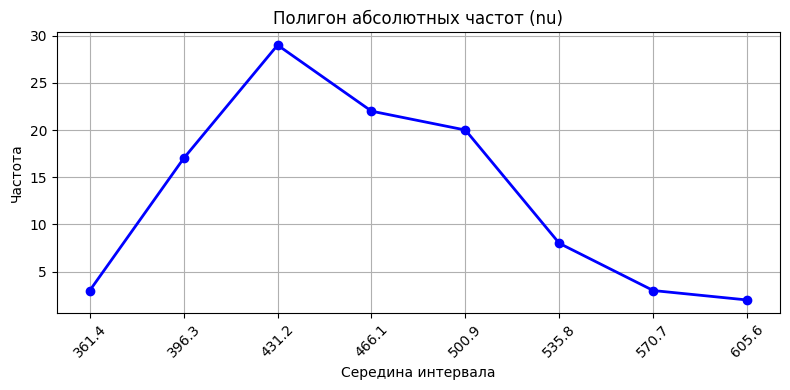

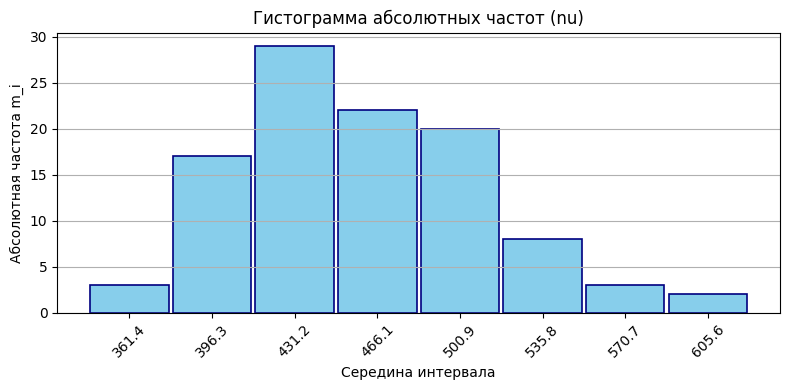

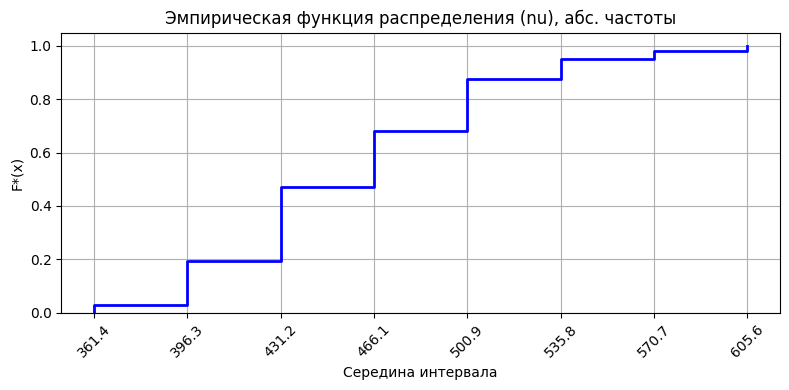


Признак: nu - относительные частоты


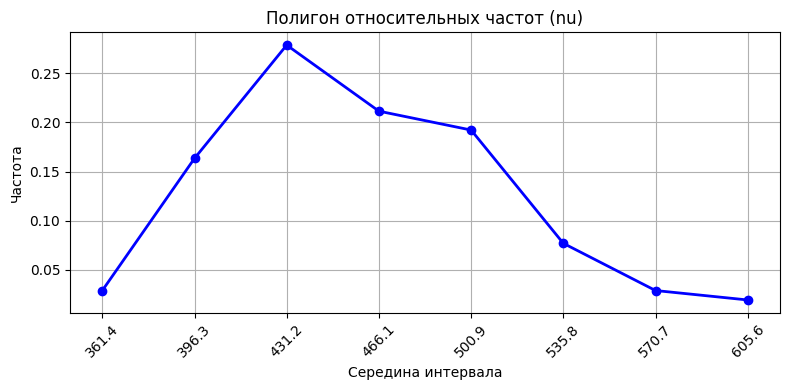

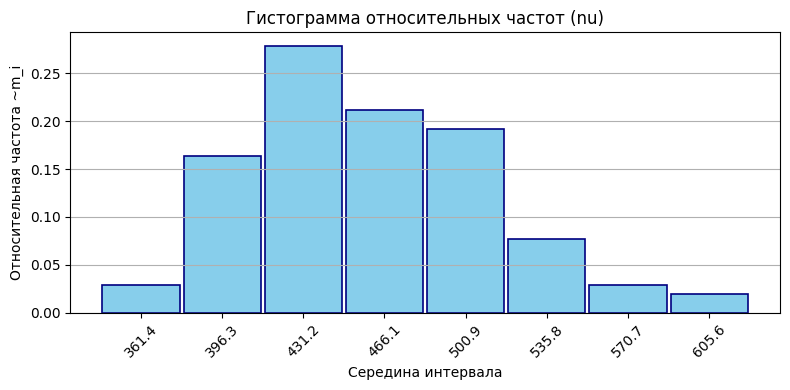

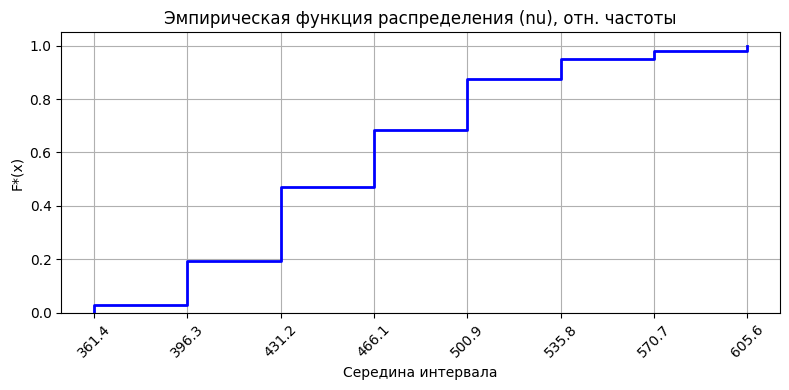


Признак: E - абсолютные частоты


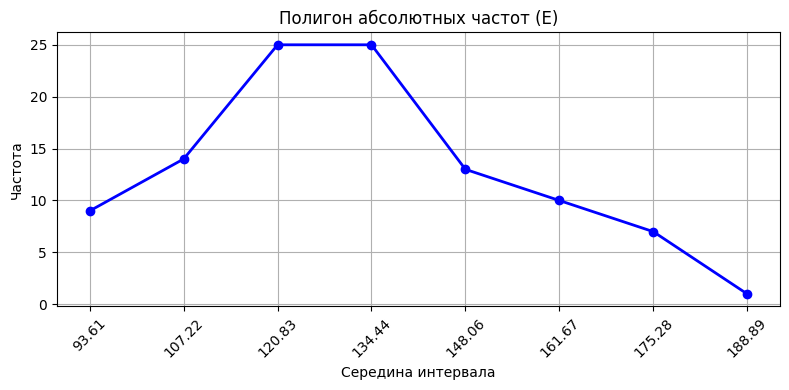

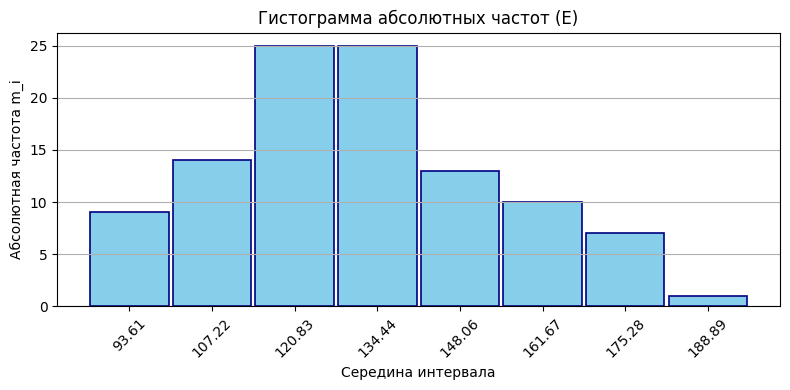

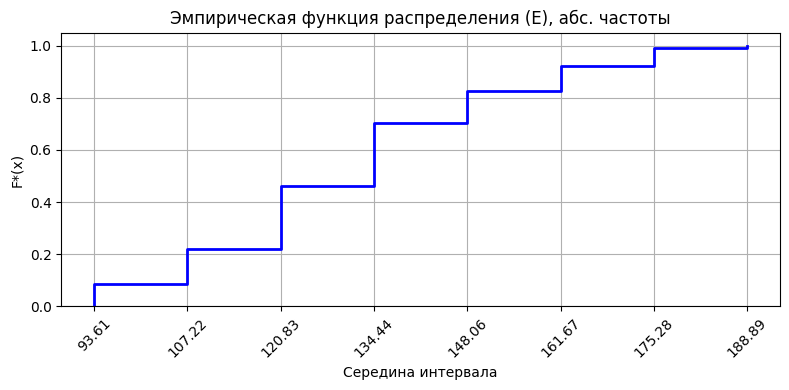


Признак: E - относительные частоты


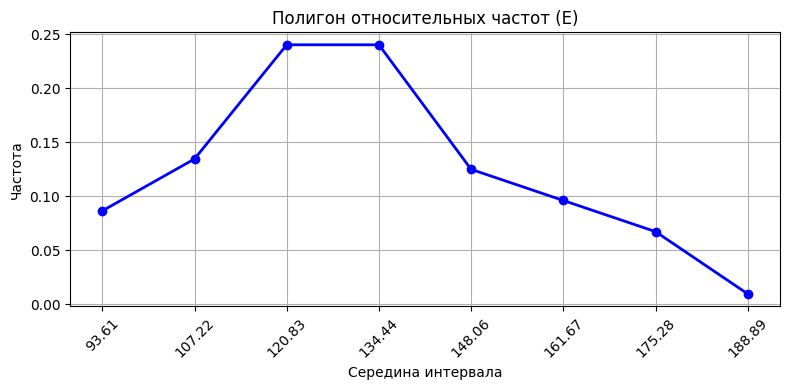

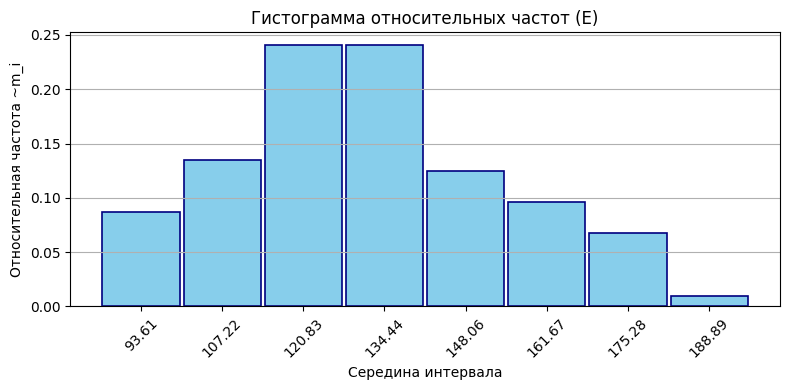

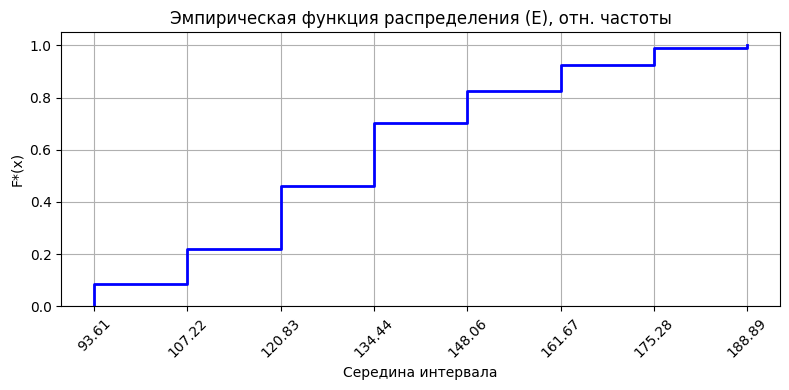

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def build_interval_data(df, column):
    data = df[column].to_numpy()
    n = len(data)
    k = math.ceil(1 + 3.322 * math.log10(n))
    xmin, xmax = float(data.min()), float(data.max())
    h = (xmax - xmin) / k
    bins = [xmin + i * h for i in range(k + 1)]
    bins[-1] += 1e-9

    midpoints, freq_abs = [], []
    for i in range(k):
        left, right = bins[i], bins[i + 1]
        mid = (left + right) / 2
        m_i = int(((data >= left) & (data < right)).sum())
        midpoints.append(mid)
        freq_abs.append(m_i)

    freq_rel = [m / n for m in freq_abs]
    return midpoints, freq_abs, freq_rel, h, bins

def plot_polygon(midpoints, freqs, title):
    plt.figure(figsize=(8, 4))
    plt.plot(midpoints, freqs, 'b-o', linewidth=2, markersize=6)
    plt.title(title)
    plt.xlabel('Середина интервала')
    plt.ylabel('Частота')
    plt.xticks(midpoints, rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_histogram(midpoints, freqs, h, title, ylabel):
    plt.figure(figsize=(8, 4))
    plt.bar(midpoints, freqs, width=h * 0.95, color='skyblue',
            edgecolor='navy', linewidth=1.2)
    plt.title(title)
    plt.xlabel('Середина интервала')
    plt.ylabel(ylabel)
    plt.xticks(midpoints, rotation=45)
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

def plot_ecdf(midpoints, freqs, title):
    n = sum(freqs)
    cum = np.cumsum(freqs) / n
    x_step = [midpoints[0]] + midpoints
    y_step = [0] + list(cum)
    plt.figure(figsize=(8, 4))
    plt.step(x_step, y_step, where='post', color='b', linewidth=2)
    plt.title(title)
    plt.xlabel('Середина интервала')
    plt.ylabel('F*(x)')
    plt.xticks(midpoints, rotation=45)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


for col in ['nu', 'E']:
    mid, fa, fr, h, bins = build_interval_data(df_sample, col)

    print(f"\nПризнак: {col} - абсолютные частоты")

    plot_polygon(mid, fa, f'Полигон абсолютных частот ({col})')
    plot_histogram(mid, fa, h, f'Гистограмма абсолютных частот ({col})', 'Абсолютная частота m_i')
    plot_ecdf(mid, fa, f'Эмпирическая функция распределения ({col}), абс. частоты')

    print(f"\nПризнак: {col} - относительные частоты")

    plot_polygon(mid, fr, f'Полигон относительных частот ({col})')
    plot_histogram(mid, fr, h, f'Гистограмма относительных частот ({col})', 'Относительная частота ~m_i')
    plot_ecdf(mid, fr, f'Эмпирическая функция распределения ({col}), отн. частоты')

#### Выводы после анализа полигонов, гистограмм и эмпирических функций

**Признак nu.** Полигон абсолютных частот имеет выраженный одиночный пик в точке 431.2 с частотой 29, после которого кривая монотонно убывает с небольшим плато на значениях 466.1 (22) и 500.9 (20). Гистограмма наглядно подтверждает это: три центральных столбца заметно выше остальных, крайние же столбцы (361.4 и 605.6) едва заметны. Левый хвост короче правого, что визуально подчёркивает правостороннюю асимметрию. Эмпирическая функция имеет наиболее крутой подъём между 396.3 и 500.9, где сосредоточено около 67% наблюдений, а затем переходит в пологий хвост. Графики относительных частот полностью повторяют форму графиков абсолютных, отличаясь лишь масштабом оси Y.

**Признак E.** Полигон абсолютных частот имеет два смежных равновысоких пика на серединах 120.83 и 134.44 с частотой 25, что на гистограмме выглядит как два одинаковых столбца в центре. Правее пика распределение резко убывает – столбцы сокращаются от 13 до 1, последний столбец (188.89) практически незаметен на фоне остальных, что указывает на правостороннюю асимметрию. Эмпирическая функция имеет два участка быстрого роста: первый – от 93.61 до 134.44, где накапливается около 70% наблюдений, второй – более пологий. Графики абсолютных и относительных частот идентичны по форме, так как относительные частоты получаются делением абсолютных на n=104, не изменяя соотношений между интервалами.

## Выводы

В ходе выполнения работы из генеральной совокупности объёмом 400 наблюдений была сформирована выборка объёмом 104 по двум вещественным признакам – объёмному весу древесины ν и модулю упругости E. Для каждого признака последовательно построены ранжированный, вариационный и интервальный ряды. Число интервалов k=8 определено по формуле Стёрджеса.

Анализ интервальных рядов и графиков показал, что оба признака имеют правостороннюю асимметрию. Для ν основная масса наблюдений сосредоточена в интервале [413.75, 448.62) с частотой 29 (27.88%), а правый хвост растянут до 623 г/см³. Для E наблюдается концентрация в двух смежных центральных интервалах с суммарной долей около 48%, при этом правый хвост резко разрежен вплоть до одиночного наблюдения в последнем интервале.

Сравнение графиков абсолютных и относительных частот подтвердило их геометрическую идентичность: форма полигонов и гистограмм не изменяется, различается лишь масштаб оси ординат. Корректность расчётов подтверждена тем, что сумма относительных частот равна 1, а последняя накопленная частота совпадает с объёмом выборки. Эмпирические функции распределения наглядно показали, в каких диапазонах значений сосредоточена основная доля наблюдений.